In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('netflix_titles.csv')
print(f"Nombre de titres : {df.shape[0]}")
print(f"Colonnes : {list(df.columns)}")
df.head()

Nombre de titres : 8807
Colonnes : ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
# Combien de contenus français sur Netflix ?
french = df[df['country'].str.contains('France', na=False)]
total = len(df)
nb_french = len(french)

print(f"Contenus français : {nb_french}")
print(f"Total Netflix : {total}")
print(f"Pourcentage : {round(nb_french/total*100, 2)}%")

Contenus français : 393
Total Netflix : 8807
Pourcentage : 4.46%


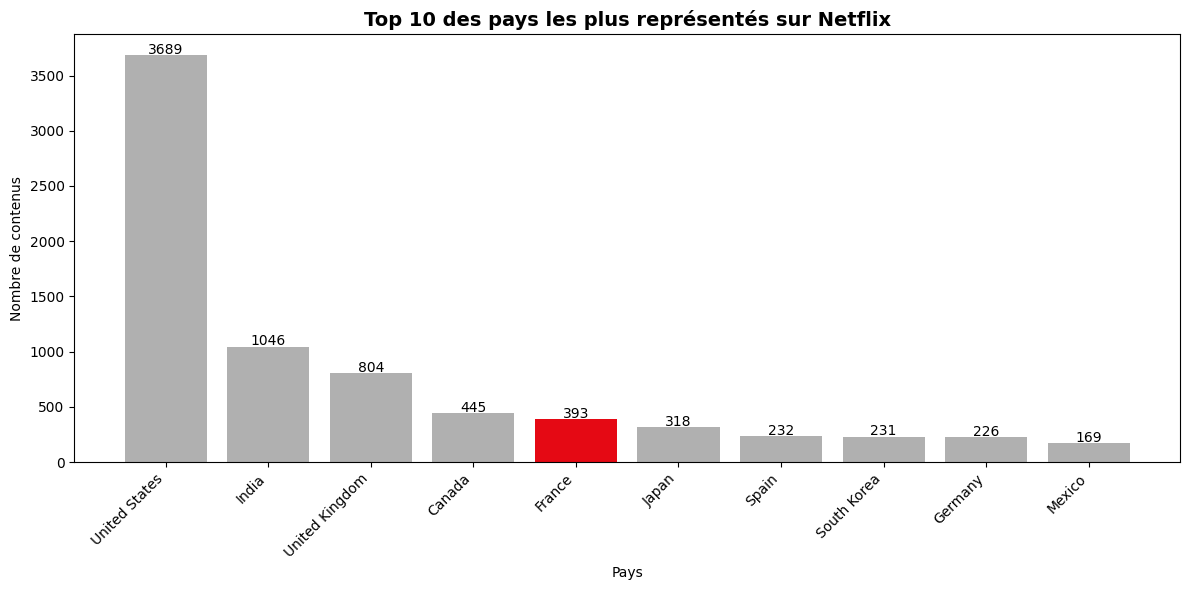

In [3]:
# Top 10 pays les plus représentés
top_pays = df['country'].str.split(', ').explode().value_counts().head(10)

plt.figure(figsize=(12, 6))
colors = ['#E50914' if x == 'France' else '#B0B0B0' for x in top_pays.index]
bars = plt.bar(top_pays.index, top_pays.values, color=colors)

plt.title('Top 10 des pays les plus représentés sur Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Pays')
plt.ylabel('Nombre de contenus')
plt.xticks(rotation=45, ha='right')

for bar, val in zip(bars, top_pays.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
             str(val), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

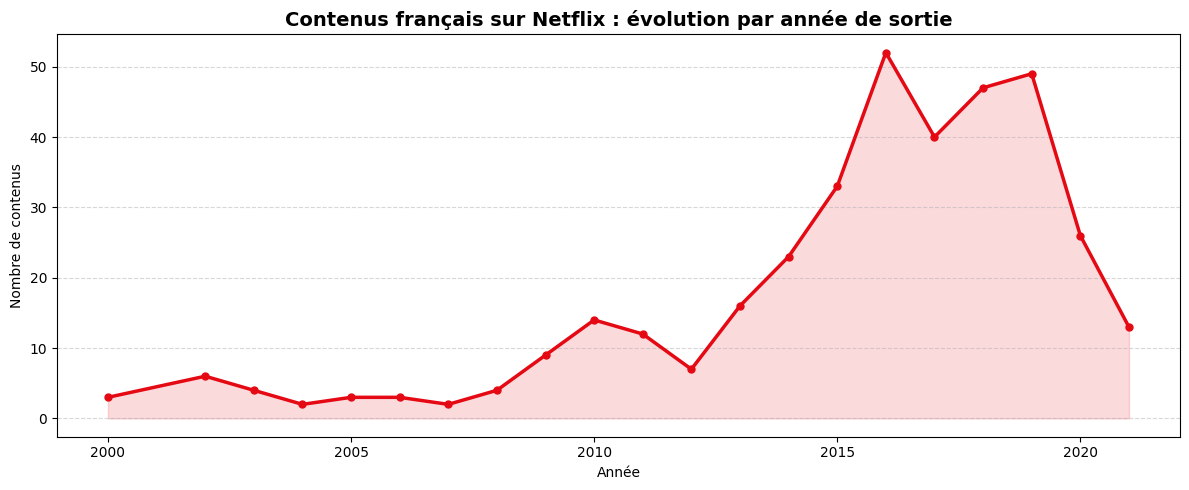

In [4]:
 # Evolution des ajouts français par année
french_by_year = french.groupby('release_year').size()
french_by_year = french_by_year[french_by_year.index >= 2000]

plt.figure(figsize=(12, 5))
plt.plot(french_by_year.index, french_by_year.values, 
         color='#E50914', linewidth=2.5, marker='o', markersize=5)
plt.fill_between(french_by_year.index, french_by_year.values, alpha=0.15, color='#E50914')

plt.title('Contenus français sur Netflix : évolution par année de sortie', fontsize=14, fontweight='bold')
plt.xlabel('Année')
plt.ylabel('Nombre de contenus')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

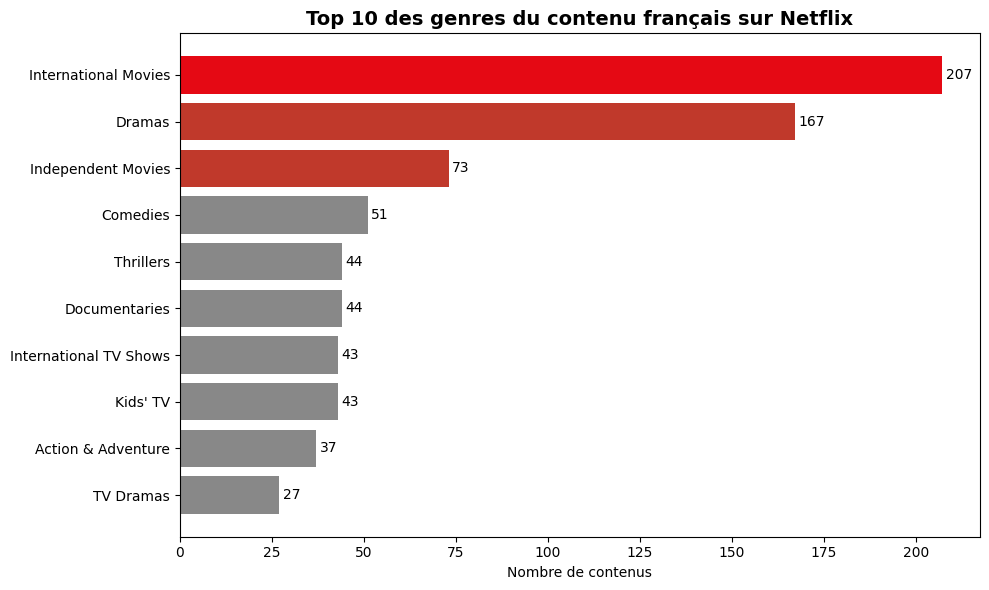

In [5]:
# Genres les plus fréquents dans le contenu français
genres_french = french['listed_in'].str.split(', ').explode().value_counts().head(10)

plt.figure(figsize=(10, 6))
colors = ['#E50914' if i == 0 else '#c0392b' if i < 3 else '#888888' 
          for i in range(len(genres_french))]

plt.barh(genres_french.index[::-1], genres_french.values[::-1], color=colors[::-1])
plt.title('Top 10 des genres du contenu français sur Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Nombre de contenus')

for i, (val, name) in enumerate(zip(genres_french.values[::-1], genres_french.index[::-1])):
    plt.text(val + 1, i, str(val), va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [6]:
print("""
=== NETFLIX FRENCH SPOTLIGHT — RÉSULTATS ===

1. La France représente seulement 4.46% du catalogue Netflix
   → 393 titres sur 8807 au total

2. La France est 5ème mondiale, derrière USA, Inde, UK, Canada
   → Mais la Corée du Sud (231 titres) la talonne malgré une
     industrie bien plus petite

3. Pic d'ajouts français en 2016-2017 (>50 titres/an)
   → Coïncide avec l'arrivée de Netflix en France en 2014

4. Genre dominant : International Movies (207)
   → Les films français sont classés "étrangers" sur Netflix
""")


=== NETFLIX FRENCH SPOTLIGHT — RÉSULTATS ===

1. La France représente seulement 4.46% du catalogue Netflix
   → 393 titres sur 8807 au total

2. La France est 5ème mondiale, derrière USA, Inde, UK, Canada
   → Mais la Corée du Sud (231 titres) la talonne malgré une
     industrie bien plus petite

3. Pic d'ajouts français en 2016-2017 (>50 titres/an)
   → Coïncide avec l'arrivée de Netflix en France en 2014

4. Genre dominant : International Movies (207)
   → Les films français sont classés "étrangers" sur Netflix

